# NB02d — Sentinel-1 SLC Download

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `02d_slc_download_v18.ipynb` |
| **Version** | v18 |
| **Pipeline position** | Acquisition. After NB02a (plan), before NB03a (SLC to coherence). |
| **Last validated** | 2026-04-XX |

## Narrative

Downloads Sentinel-1 SLC (Single Look Complex) zip archives from Copernicus Data
Space, with ASF (Alaska Satellite Facility) as fallback. SLC products are the raw
input for InSAR coherence computation in NB03a.

Downloads are plan-driven: the notebook reads `nb02a_scene_plan.json`, filters by
tier, rechecks disk for already-downloaded files, and downloads only what is missing.
No scene selection logic here — that was done in NB02a.

SLC files are large (~4-8 GB each). The notebook enforces `MIN_SLC_SIZE=3GB` to
reject truncated or corrupt downloads. Failed downloads are retried automatically
when `RETRY_FAILED=True`.

## Scientific Rationale
SLC products preserve phase information required for InSAR coherence estimation.
Coherence measures the correlation between two SAR acquisitions and drops when the
scattering surface changes — building destruction causes coherence loss. Biweekly
repeat-pass coherence from consecutive SLC pairs is one of the strongest damage
indicators (Yun et al. 2015, Aimaiti et al. 2022). Dietrich et al. (2025) use
coherence-derived statistics (min, max, mean, median, std, kurtosis, skewness)
as 14 of their 28 features.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a Cell PLAN | JSON (SLC scene list per city) |
| Copernicus Data Space | Online (primary) | Sentinel-1 SLC zips |
| ASF Earthdata | Online (fallback) | Sentinel-1 SLC zips |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| SLC zip files | `RAW_SLC_ZIP/{scene_name}.zip` | NB03a (coherence processing) |
| Updated `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | NB03a (status tracking) |

## Prerequisites
- NB02a must have run (plan exists with SLC scene list)
- Copernicus Data Space credentials in `global_setup`
- ASF Earthdata credentials in `global_setup` (fallback)
- Internet access
- Sufficient disk space (~4-8 GB per SLC scene)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Copernicus primary, ASF fallback | CDSE is faster but less reliable; ASF is stable | Empirical |
| MIN_SLC_SIZE=3GB | Reject truncated downloads | Empirical threshold |
| Plan-driven, no re-selection | Separation of concerns (selection in NB02a) | Architecture principle |
| scene_download.py shared module | Same download logic as NB02b/c | Code reuse |

## Known Limitations
- SLC downloads can take hours for large city sets (50+ scenes per city)
- Copernicus Data Space rate limits may throttle concurrent downloads
- No pre-battle SLC pairs for cities with ongoing conflicts (NB02a BUG)

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (TIER_SELECTION, MIN_SLC_SIZE, RETRY_FAILED) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3 | Cell 14B2 | Scene download functions (scene_download.py) | **Core** |
| 4-5 | Cell LOAD-PLAN | Load plan + filter + recheck disk | **Core** |
| 6-7 | Cell DL-SLC | Bulk SLC download (Copernicus + ASF fallback) | **Core** |
| 8 | Cell SUMMARY | Save updated plan + completion summary | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Sentinel-1 SLC | DL-SLC | SLC product description, dual-source download |
| 3.3 Preprocessing — Acquisition Pipeline | LOAD-PLAN, DL-SLC | Plan-driven download, size validation |

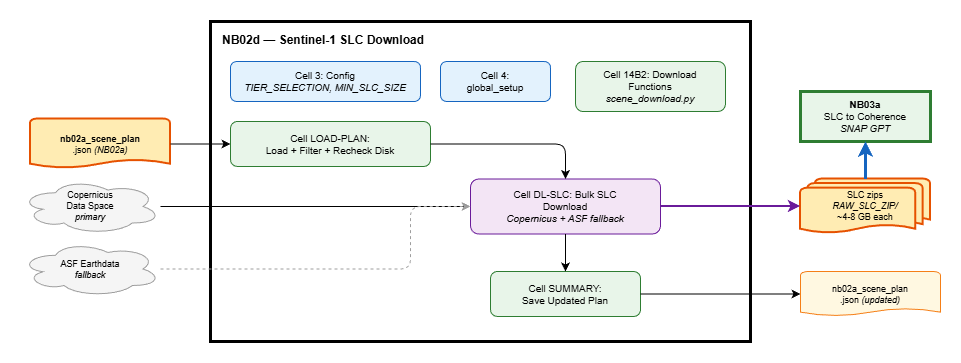

In [13]:
# @title CELL 3: NB02d CONFIG
TIER_SELECTION = [0,1,2,3]
CITY_SELECTION = None
FORCE_RERUN = False
DRY_RUN = False
MAX_DOWNLOADS = None
RETRY_FAILED = True
MIN_SLC_SIZE = 3e9

In [14]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-04-10 07:55:05
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 31 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------

  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
--

In [15]:
# @title CELL 14B2: SCENE DOWNLOAD FUNCTIONS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import scene_download
importlib.reload(scene_download)
from scene_download import init as init_scene_download

init_scene_download(
    temp_download_dir=TEMP_DOWNLOAD_DIR,
    raw_slc_zip=RAW_SLC_ZIP,
    data_root=DATA_ROOT,
    copernicus_username=COPERNICUS_USERNAME,
    copernicus_password=COPERNICUS_PASSWORD,
)

from scene_download import (
    download_scene, download_scene_pair, download_scene_chain,
    download_orbit_files, cleanup_temp_scenes,
    download_scene_copernicus, download_scene_asf,
    get_copernicus_token, lookup_copernicus_id,
)


CELL 14B2: SCENE DOWNLOAD FUNCTIONS

  Functions defined:
    get_copernicus_token()
    lookup_copernicus_id(scene_name)
    download_scene_copernicus(scene_id, scene_name, output_dir)
    download_scene_asf(scene_name, output_dir, earthdata_user, earthdata_pass)
    download_scene(scene_metadata, output_dir, prefer_copernicus)
    download_scene_pair(scene1, scene2, output_dir, prefer_copernicus)
    download_orbit_files(scene_paths, orbit_source_dir, orbit_dest_dir)
    cleanup_temp_scenes(scene_names, keep_safe)
    download_scene_chain(chain, output_dir, prefer_copernicus)

  Config:
    TEMP_DOWNLOAD_DIR = /content/snap_work/temp
    RAW_SLC_ZIP = /content/masterthesis_local/data/raw_slc_zip
    Download preference: Copernicus FIRST, ASF fallback

CELL 14B2 COMPLETE


# LOAD PLAN + RECHECK DISK

In [16]:
# @title CELL LOAD-PLAN: LOAD PLAN + FILTER + RECHECK DISK
import json, re
from pathlib import Path
from datetime import datetime

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
if not PLAN_FILE.exists():
    raise FileNotFoundError(f"Plan not found: {PLAN_FILE}\nRun NB02a first.")

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print("=" * 80)
print("NB02d: LOADING PLAN + RECHECKING SLC ZIPS")
print("=" * 80)

slc_plan = {}
for city, plan in PLAN.items():
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city not in CITY_SELECTION:
        continue
    slc_plan[city] = plan

print(f"  Cities after filter: {len(slc_plan)}")

# Recheck SLC zips
RAW_SLC_ZIP.mkdir(parents=True, exist_ok=True)
slc_on_disk = set()
for f in RAW_SLC_ZIP.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > MIN_SLC_SIZE:
        slc_on_disk.add(f.name.replace('.SAFE.zip', '').replace('.zip', ''))

download_queue = []
on_disk_count = 0

for city, plan in sorted(slc_plan.items(), key=lambda x: (x[1]['tier'], x[0])):
    for entry in plan.get('slc', []):
        scene_name = entry.get('scene_name', '')
        if scene_name and scene_name in slc_on_disk:
            entry['status'] = 'on_disk'
            on_disk_count += 1
        elif entry['status'] == 'on_disk':
            entry['status'] = 'to_download'
        if entry['status'] == 'to_download' and entry.get('scene_id'):
            download_queue.append({
                'city': city, 'tier': plan['tier'],
                'period': entry.get('period', ''), 'date': entry.get('date', ''),
                'scene_name': scene_name, 'scene_id': entry['scene_id'],
                'orbit': entry.get('orbit'),
            })

print(f"  On disk: {on_disk_count}")
print(f"  To download: {len(download_queue)}")
download_queue.sort(key=lambda x: (x['tier'], x['city'], x['date']))
print("=" * 80)

NB02d: LOADING PLAN + RECHECKING SLC ZIPS
  Cities after filter: 50
  On disk: 1841
  To download: 431


# DOWNLOAD

In [17]:
# @title CELL DL-SLC: BULK SLC ZIP DOWNLOADER (PLAN-BASED)
# =============================================================================
# Downloads SLC zips based on slc_download_plan.json from DL-SYNC.
# Just downloads what the plan says is missing. No scene selection here.
#
# Requires: Cell 4+4A (paths), Cell 14B2 (download functions), Cell DL-SYNC
# =============================================================================

CELL_ID = "cell_dl_slc"

# CONFIGURATION
DRY_RUN = False                 # True = report only, no downloads
MAX_DOWNLOADS = None            # None = all, or int to limit
RETRY_FAILED = True             # retry previously failed downloads

import json
import os
import re
import time
from pathlib import Path
from datetime import datetime

print("=" * 80)
print("CELL DL-SLC: BULK SLC ZIP DOWNLOADER (PLAN-BASED)")
print("=" * 80)
print(f"  Timestamp: {datetime.now().isoformat()}")
print(f"  DRY_RUN: {DRY_RUN}")
print(f"  MAX_DOWNLOADS: {MAX_DOWNLOADS}")

# =============================================================================
# USE PLAN (download_queue + slc_plan from Cell LOAD-PLAN)
# =============================================================================

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
print(f"  Plan: {PLAN_FILE}")
print(f"  Cities from plan: {len(slc_plan)}")
print(f"  Download queue: {len(download_queue)} scenes to download")

# build city_orbit_map from plan (needed by tracker)
city_orbit_map = {c: p.get('orbit') for c, p in slc_plan.items() if p.get('orbit')}

if not download_queue:
    print("\n  Nothing to download - all SLC scenes are on disk!")
    print("=" * 80)

# =============================================================================
# TRACKER
# =============================================================================

DL_TRACKER_FILE = RAW_SLC_ZIP / 'download_tracker.json'

def load_dl_tracker():
    if DL_TRACKER_FILE.exists():
        with open(DL_TRACKER_FILE, 'r') as f:
            return json.load(f)
    return {'created': datetime.now().isoformat(), 'downloads': {}, 'cities': {}}

def save_dl_tracker(tracker):
    tracker['last_updated'] = datetime.now().isoformat()
    with open(DL_TRACKER_FILE, 'w') as f:
        json.dump(tracker, f, indent=2)

dl_tracker = load_dl_tracker()
print(f"  Tracker: {len(dl_tracker.get('downloads', {}))} scenes tracked")

# =============================================================================
# VERIFY PLAN AGAINST CURRENT DISK STATE (re-check before downloading)
# =============================================================================
print(f"\n{'='*80}")
print("VERIFYING PLAN AGAINST DISK")
print(f"{'='*80}")

# Quick rescan
current_on_disk = set()
for f in RAW_SLC_ZIP.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > MIN_SLC_SIZE:
        name = f.name.replace('.SAFE.zip', '').replace('.zip', '')
        current_on_disk.add(name)

# Also check by date for fuzzy match
disk_by_date = {}
for name in current_on_disk:
    m = re.search(r'(\d{8})T', name)
    if m:
        d = f"{m.group(1)[:4]}-{m.group(1)[4:6]}-{m.group(1)[6:8]}"
        if d not in disk_by_date:
            disk_by_date[d] = []
        disk_by_date[d].append(name)

# Filter queue: skip scenes that appeared on disk since plan was created
actual_queue = []
already_done = 0
for item in download_queue:
    name = item.get('scene_name', item.get('name', ''))
    base = name[:-5] if name.endswith('.SAFE') else name
    if base in current_on_disk:
        already_done += 1
        continue
    # fuzzy date match
    m = re.search(r'(\d{8})T', base)
    if m:
        d = f"{m.group(1)[:4]}-{m.group(1)[4:6]}-{m.group(1)[6:8]}"
        if d in disk_by_date:
            already_done += 1
            continue
    # check tracker for previous failure
    tracker_entry = dl_tracker.get('downloads', {}).get(base, {})
    if tracker_entry.get('status', '').startswith('failed') and not RETRY_FAILED:
        print(f"    Skipping {base[:60]}... (previously failed)")
        continue

    actual_queue.append(item)

if already_done > 0:
    print(f"  {already_done} scenes appeared on disk since plan was created - skipping")
print(f"  {len(actual_queue)} scenes still need downloading")

if MAX_DOWNLOADS:
    actual_queue = actual_queue[:MAX_DOWNLOADS]
    print(f"  Limited to {MAX_DOWNLOADS} downloads")

# =============================================================================
# DOWNLOAD
# =============================================================================
if actual_queue and not DRY_RUN:
    print(f"\n{'='*80}")
    print(f"DOWNLOADING {len(actual_queue)} SLC SCENES")
    print(f"{'='*80}")

    success = 0
    failed = 0

    for idx, item in enumerate(actual_queue):
        name = item.get('scene_name', item.get('name', ''))
        sid = item.get('scene_id', item.get('id', ''))
        city = item['city']
        purpose = item.get('period', item.get('purpose', ''))
        source = item.get('source', 'copernicus')

        base = name[:-5] if name.endswith('.SAFE') else name
        safe_name = f"{base}.SAFE" if not name.endswith('.SAFE') else name

        print(f"\n  [{idx+1}/{len(actual_queue)}] {base[:70]}")
        print(f"    City: {city}, Purpose: {purpose}")

        t0 = time.time()

        # Try Copernicus first
        result_name = base
        result_status = 'failed'
        result_size = 0

        try:
            print(f"    Trying Copernicus (id={sid[:20]}...)...")
            zip_path = download_scene_copernicus(sid, safe_name, RAW_SLC_ZIP, extract=False)
            if zip_path and Path(zip_path).exists():
                fsize = Path(zip_path).stat().st_size
                if fsize > MIN_SLC_SIZE:
                    result_status = 'complete'
                    result_size = fsize / 1e9
                    print(f"    OK: {result_size:.1f} GB in {time.time()-t0:.0f}s")
                else:
                    Path(zip_path).unlink()
                    print(f"    Too small ({fsize/1e9:.1f} GB) - deleted")
        except Exception as e:
            print(f"    Copernicus failed: {e}")

        # ASF fallback
        if result_status != 'complete':
            try:
                print(f"    Trying ASF fallback...")
                zip_path = download_scene_asf(safe_name, RAW_SLC_ZIP, extract=False)
                if zip_path and Path(zip_path).exists():
                    fsize = Path(zip_path).stat().st_size
                    if fsize > MIN_SLC_SIZE:
                        result_status = 'complete'
                        result_size = fsize / 1e9
                        print(f"    ASF OK: {result_size:.1f} GB in {time.time()-t0:.0f}s")
                    else:
                        Path(zip_path).unlink()
                        print(f"    Too small ({fsize/1e9:.1f} GB) - deleted")
                if result_status != 'complete':
                    raise ValueError("ASF download returned nothing usable")
            except Exception as e:
                print(f"    ASF also failed: {e}")
                result_status = f'failed: {str(e)[:100]}'

        # Update tracker
        dl_tracker['downloads'][result_name] = {
            'status': result_status,
            'size_gb': result_size,
            'city': city,
            'purpose': purpose,
            'timestamp': datetime.now().isoformat()
        }
        if result_status == 'complete':
            success += 1
            # write success back to plan
            for e in slc_plan.get(city, {}).get('slc', []):
                sn = e.get('scene_name', '')
                if sn and (sn == base or sn == name):
                    e['status'] = 'on_disk'
                    break
            with open(PLAN_FILE) as rf:
                full_plan = json.load(rf)
            full_plan.update(slc_plan)
            with open(PLAN_FILE, 'w') as pf:
                json.dump(full_plan, pf, indent=2, default=str)
        else:
            failed += 1

        # Save tracker periodically
        if (idx + 1) % 5 == 0 or idx == len(actual_queue) - 1:
            dl_tracker['city_orbits'] = {k: int(v) for k, v in city_orbit_map.items() if v}
            save_dl_tracker(dl_tracker)

    print(f"\n  Download complete: {success} success, {failed} failed")

elif DRY_RUN and actual_queue:
    print(f"\n  DRY RUN - would download {len(actual_queue)} scenes:")
    for item in actual_queue[:20]:
        print(f"    {item.get('scene_name', item.get('name', ''))[:60]}... ({item['city']}, {item.get('period', item.get('purpose', ''))})")
    if len(actual_queue) > 20:
        print(f"    ... and {len(actual_queue)-20} more")

# =============================================================================
# FINAL TRACKER UPDATE
# =============================================================================
dl_tracker['city_orbits'] = {k: int(v) for k, v in city_orbit_map.items() if v}
save_dl_tracker(dl_tracker)

# =============================================================================
# SUMMARY
# =============================================================================
print(f"\n{'='*80}")
print("DL-SLC SUMMARY")
print(f"{'='*80}")

# Rescan disk
final_count = 0
final_gb = 0
for f in RAW_SLC_ZIP.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > MIN_SLC_SIZE:
        final_count += 1
        final_gb += f.stat().st_size / 1e9

print(f"  SLC zips on disk: {final_count} ({final_gb:.0f} GB)")
print(f"  Tracker: {DL_TRACKER_FILE}")

# Per-orbit summary
orbit_counts = {}
for f in RAW_SLC_ZIP.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > MIN_SLC_SIZE:
        m = re.search(r'_(\d{6})_[A-F0-9]+', f.name)
        if m:
            orbit = int(m.group(1))
            orbit_counts[orbit] = orbit_counts.get(orbit, 0) + 1

print(f"  By orbit: {dict(sorted(orbit_counts.items()))}")
print("=" * 80)


CELL DL-SLC: BULK SLC ZIP DOWNLOADER (PLAN-BASED)
  Timestamp: 2026-04-10T07:55:44.824225
  DRY_RUN: False
  MAX_DOWNLOADS: None
  Plan: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
  Cities from plan: 50
  Download queue: 431 scenes to download
  Tracker: 989 scenes tracked

VERIFYING PLAN AGAINST DISK
  431 scenes appeared on disk since plan was created - skipping
  0 scenes still need downloading

DL-SLC SUMMARY
  SLC zips on disk: 953 (7612 GB)
  Tracker: /content/masterthesis_local/data/raw_slc_zip/download_tracker.json
  By orbit: {3838: 1, 4013: 1, 4188: 1, 5165: 1, 5340: 1, 5515: 1, 5690: 1, 5814: 1, 5865: 1, 6813: 1, 6864: 1, 7039: 1, 7090: 1, 29914: 1, 30089: 1, 41007: 1, 41014: 1, 41036: 1, 41065: 2, 41087: 1, 41109: 1, 41116: 1, 41138: 1, 41153: 1, 41167: 1, 41182: 1, 41189: 1, 41211: 1, 41240: 2, 41262: 1, 41284: 1, 41291: 1, 41313: 1, 41328: 1, 41342: 1, 41357: 1, 41364: 1, 41386: 1, 41415: 2, 41437: 1, 41459: 1, 41466: 1, 41488: 1, 41503: 1, 41517: 1,

In [18]:
# @title CELL SUMMARY: NB02d COMPLETE
with open(PLAN_FILE, 'w') as f:
    json.dump(PLAN, f, indent=2, default=str)
print("=" * 80)
print("NB02d SLC DOWNLOAD - COMPLETE")
print(f"  Plan updated: {PLAN_FILE}")
print("=" * 80)

NB02d SLC DOWNLOAD - COMPLETE
  Plan updated: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
